## Feladat 1: Iris adathalmaz betöltése

Ebben a feladatban az Iris adathalmazt kell betöltened a `sklearn.datasets` modulból.

Az Iris egy klasszikus gépi tanulási adathalmaz, amely három különböző virágfajtát tartalmaz, és négy mérhető jellemző (pl. csészelevél és szirom méretek) alapján írja le az egyedeket.

A feladat során:
- töltsd be az adathalmazt a `load_iris()` függvénnyel
- válaszd szét az adatokat:
  - **X**: bemeneti jellemzők
  - **y**: célváltozó (osztályok)

In [1]:
from sklearn.datasets import load_iris

# Adathalmaz betöltése
iris = load_iris()

# Bemeneti változók (feature-ök)
X = iris.data

# Célváltozó (osztályok)
y = iris.target

## Feladat 2: Adatok felosztása és standardizálása

Az Iris adathalmazt oszd fel tanító és teszt halmazra.

A felosztás legyen:
- 80% tanító adat
- 20% teszt adat
- `random_state = 42` a reprodukálhatóság érdekében

Ezután standardizáld a bemeneti változókat, mert az SVM algoritmus érzékeny a skálára.

A standardizálás lépései:
- illeszd a skálázót a tanító adatokra
- transzformáld a tanító és teszt halmazt is


In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Standardizálás
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Feladat 3: SVM modell tanítása és kiértékelése

Taníts egy Support Vector Machine (SVM) modellt a standardizált tanító adatokon.

Ezután értékeld ki a modellt mind a tanító, mind a teszt halmazon, és számítsd ki a pontosságot (accuracy).

A cél, hogy összehasonlítsd a modell teljesítményét a tanító és teszt adatokon, és megfigyeld, van-e túltanulás.

In [3]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# SVM modell tanítása
model = SVC()
model.fit(X_train_scaled, y_train)

# Predikció tanító halmazon
y_train_pred = model.predict(X_train_scaled)
train_acc = accuracy_score(y_train, y_train_pred)

# Predikció teszt halmazon
y_test_pred = model.predict(X_test_scaled)
test_acc = accuracy_score(y_test, y_test_pred)

print(f"Train accuracy: {train_acc:.3f}")
print(f"Test accuracy:  {test_acc:.3f}")

Train accuracy: 0.967
Test accuracy:  1.000


## Feladat 4: Wine adathalmaz és PCA

Ebben a feladatban a Wine (bor) adathalmazt kell betöltened a `sklearn.datasets` modulból.

Az adathalmaz 13 különböző kémiai jellemzőt tartalmaz borokból, és 3 különböző borosztályt különböztet meg.

A feladat célja a dimenziócsökkentés PCA segítségével.

Lépések:
- töltsd be a Wine adathalmazt
- válaszd szét X-re (feature-ök) és y-ra (osztályok)
- standardizáld az X-et
- alkalmazz PCA-t **3 főkomponensre**
- transzformáld az adatokat az új térbe

In [4]:
from sklearn.datasets import load_wine
from sklearn.decomposition import PCA

# Adatok betöltése
wine = load_wine()
X = wine.data
y = wine.target

# Standardizálás
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA (3 komponens)
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

# Magyarázott variancia
print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total explained variance:", sum(pca.explained_variance_ratio_))

Explained variance ratio: [0.36198848 0.1920749  0.11123631]
Total explained variance: 0.6652996889318524


## Feladat 5: PCA eredmény vizualizálása

Az előző feladatban elkészített 3 dimenziós PCA transzformációból most vizualizáld az első két főkomponenst.

A cél, hogy megnézd, mennyire szeparálhatók a borosztályok egy 2D vetületben.

Lépések:
- használd a PCA-val kapott transzformált adatot
- ábrázold az 1. és 2. főkomponenst egy scatter ploton
- a pontokat színezd az osztályok (y) szerint

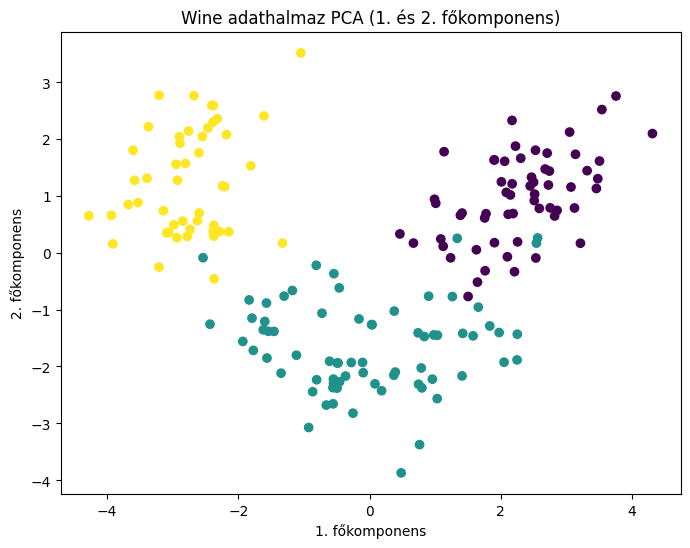

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y)

plt.xlabel("1. főkomponens")
plt.ylabel("2. főkomponens")
plt.title("Wine adathalmaz PCA (1. és 2. főkomponens)")
plt.show()